# Correspondence Analysis (CA and MCA)

## Overview

Correspondence Analysis is PCA for contingency tables and count/frequency matrices. It decomposes the chi-squared statistic to find low-dimensional representations of the association between rows and columns.

**When to use CA:**
- Two-way contingency tables (rows × columns)
- Species × site abundance matrices
- Survey response × demographic group crosstabulations

**Multiple Correspondence Analysis (MCA)** extends CA to datasets with multiple categorical variables — analogous to PCA for categorical data.

**CA vs. PCA:**

| | PCA | CA |
|---|---|---|
| Input | Continuous features | Counts / frequency tables |
| Distance | Euclidean | Chi-squared (profile distance) |
| Axes | Linear combinations | Weighted chi-squared components |
| Joint plot | Biplot | Symmetric or asymmetric map |
| Scaling | Manual | Built-in row/column profile scaling |

**Biplot interpretation (symmetric scaling):** Rows and columns near each other in the CA biplot are associated — that row category co-occurs frequently with that column category relative to their marginal frequencies.

---

## Setup

In [3]:
library(tidyverse)
library(ggplot2)
library(ca)            # ca(), mjca()
library(FactoMineR)    # CA(), MCA() — richer output
library(factoextra)    # fviz_ca_biplot(), fviz_mca_biplot()
library(patchwork)

set.seed(42)

# ── Dataset 1: species × site abundance matrix (community ecology) ────────────
n_sites   <- 30
n_species <- 12

# Sites split into 3 environmental gradients
make_site_abundances <- function(site_type, n) {
  base <- switch(site_type,
    "reference" = c(8,7,6,5,4,3,1,1,0,0,0,0),
    "restored"  = c(4,4,4,4,3,3,2,2,1,1,0,0),
    "degraded"  = c(0,0,0,1,1,2,3,4,5,6,7,8)
  )
  t(replicate(n, pmax(0, round(base + rnorm(n_species, 0, 1.5)))))
}

species_mat <- rbind(
  make_site_abundances("reference", 10),
  make_site_abundances("restored",  10),
  make_site_abundances("degraded",  10)
)
rownames(species_mat) <- paste0(rep(c("ref","res","deg"), each=10),
                                 "_", 1:30)
colnames(species_mat) <- paste0("sp", 1:n_species)
site_type <- rep(c("reference","restored","degraded"), each=10)

cat("Species abundance matrix:", nrow(species_mat), "sites ×",
    ncol(species_mat), "species\n")

# ── Dataset 2: MCA — survey with multiple categorical variables ───────────────
n_resp <- 200
survey_data <- tibble(
  habitat     = sample(c("urban","suburban","rural"),    n_resp, replace=TRUE, prob=c(.3,.4,.3)),
  disturbance = sample(c("low","medium","high"),         n_resp, replace=TRUE, prob=c(.35,.35,.3)),
  vegetation  = sample(c("native","mixed","exotic"),     n_resp, replace=TRUE, prob=c(.3,.4,.3)),
  water_body  = sample(c("stream","wetland","none"),     n_resp, replace=TRUE, prob=c(.35,.3,.35))
)

Warning message:
"package 'ca' was built under R version 4.4.3"


Welcome! Want to learn more? See two factoextra-related books at https://goo.gl/ve3WBa

Warning message:
"package 'patchwork' was built under R version 4.4.3"


Species abundance matrix: 30 sites × 12 species


---

## Correspondence Analysis of Species × Site Matrix

Inertia (variance) explained by each dimension:
      eigenvalue variance.percent cumulative.variance.percent
Dim.1      0.479           73.743                      73.743
Dim.2      0.037            5.676                      79.419
Dim.3      0.034            5.258                      84.678
Dim.4      0.027            4.112                      88.789
Dim.5      0.016            2.535                      91.325


Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Warning message:
"No shared levels found between `names(values)` of the manual scale and the
data's fill values."


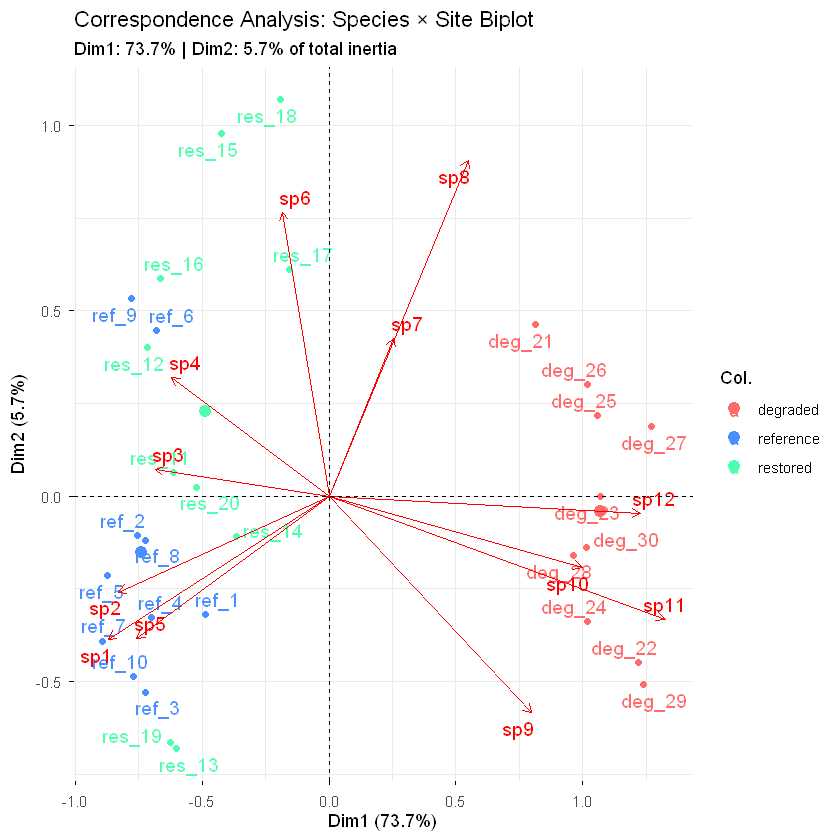

In [4]:
ca_fit <- FactoMineR::CA(
  species_mat,
  ncp    = 5,
  graph  = FALSE
)

# Variance explained by each dimension
cat("Inertia (variance) explained by each dimension:\n")
eig <- get_eigenvalue(ca_fit)
print(round(eig[1:5,], 3))

# ── Symmetric biplot ──────────────────────────────────────────────────────────
factoextra::fviz_ca_biplot(
  ca_fit,
  map          = "symbiplot",   # symmetric: both rows and cols in principal coords
  arrow        = c(FALSE, TRUE), # arrows for columns (species), points for rows (sites)
  col.row      = site_type,
  palette      = c(reference="#4a8fff",restored="#4fffb0",degraded="#ff6b6b"),
  repel        = TRUE,
  ggtheme      = theme_minimal()
) +
  labs(
    title    = "Correspondence Analysis: Species × Site Biplot",
    subtitle = sprintf("Dim1: %.1f%% | Dim2: %.1f%% of total inertia",
                       eig[1,2], eig[2,2])
  )
# Interpretation:
# Sites near a species arrow tip → that species is abundant at those sites
# Sites on opposite side from species → species absent or rare

---

## Multiple Correspondence Analysis

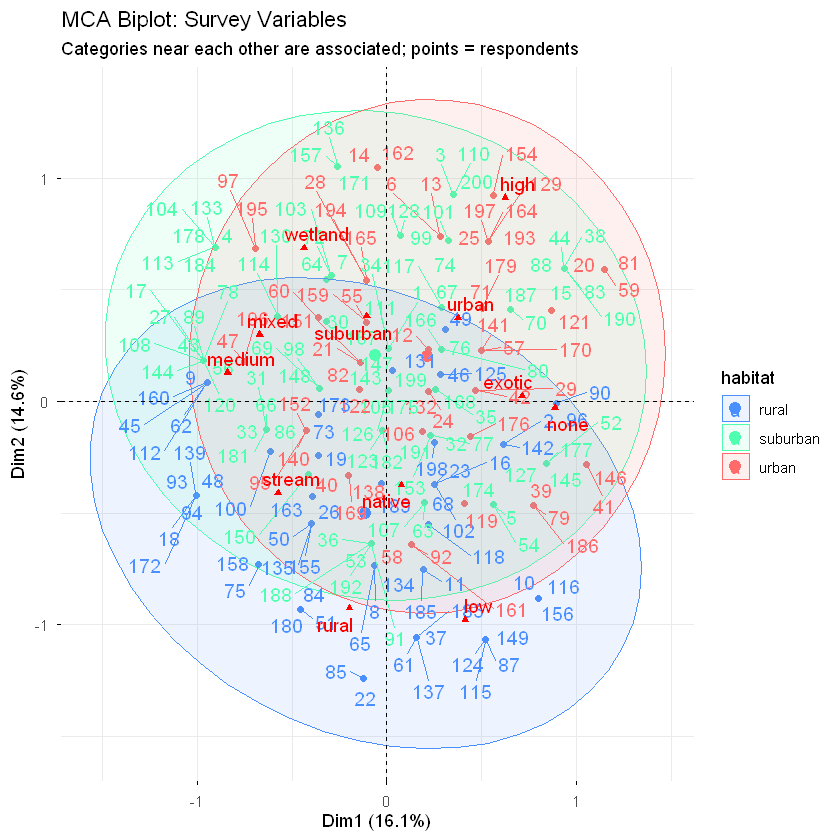

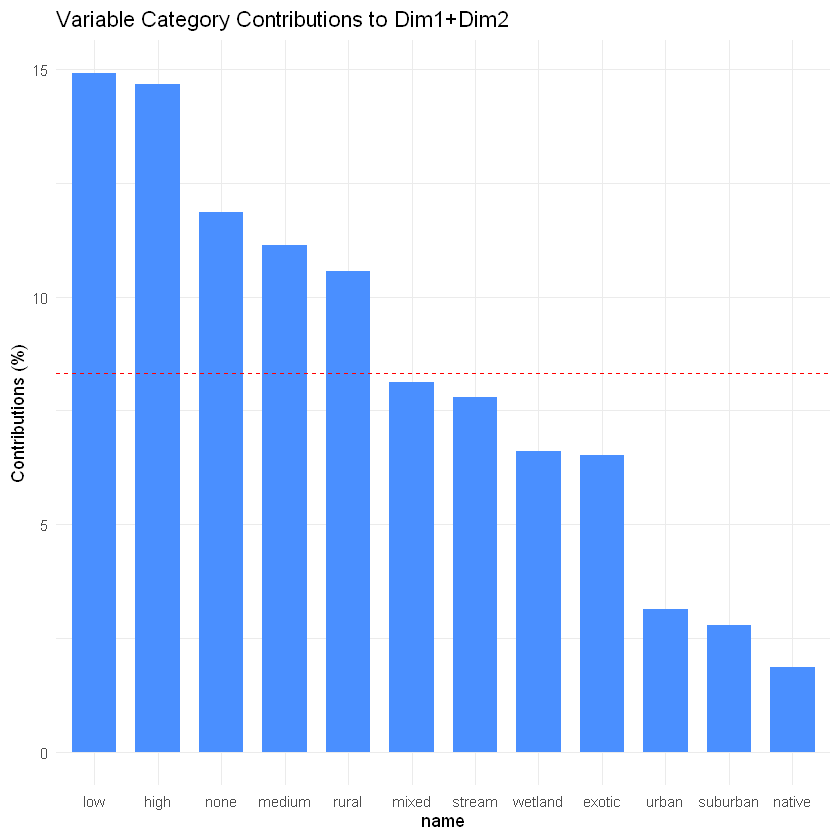

In [5]:
mca_fit <- FactoMineR::MCA(
  survey_data,
  ncp   = 5,
  graph = FALSE
)

# ── MCA biplot: variable categories ──────────────────────────────────────────
factoextra::fviz_mca_biplot(
  mca_fit,
  repel      = TRUE,
  habillage  = "habitat",
  palette    = c("#4a8fff","#4fffb0","#ff6b6b"),
  addEllipses= TRUE,
  ggtheme    = theme_minimal()
) +
  labs(title="MCA Biplot: Survey Variables",
       subtitle="Categories near each other are associated; points = respondents")

# ── Variable contributions ────────────────────────────────────────────────────
factoextra::fviz_contrib(
  mca_fit, choice="var", axes=1:2, top=12,
  fill="#4a8fff", color=NA
) +
  theme_minimal() +
  labs(title="Variable Category Contributions to Dim1+Dim2")

---

## Common Pitfalls

**1. Interpreting distances between row and column points in symmetric biplots**  
In a symmetric CA biplot, only the distances between row points (among themselves) or column points (among themselves) are meaningful. The distance between a row point and a column point should not be interpreted as proximity in an absolute sense. Use asymmetric biplots (`map="rowprincipal"`) if you want to interpret row–column proximity directly.

**2. Applying CA to matrices with many zeros**  
CA uses chi-squared profile distances, which break down when many cells are zero (the profile of a zero row has no information). For sparse species–site matrices (>50% zeros), consider decostand transformation, Hellinger distance, or nMDS with Bray-Curtis in `vegan` — see `nmds.ipynb`.

**3. Not checking the total inertia explained**  
Report the percentage of total inertia (equivalent to chi-squared variance) explained by Dim1+Dim2. If this is below 40%, the biplot shows a small and potentially misleading portion of the structure. Consider plotting Dim1 vs. Dim3 and Dim2 vs. Dim3 as supplementary figures.

**4. Using MCA on variables with very different numbers of categories**  
MCA results are influenced by variables with many categories, which contribute more inertia. Consider collapsing rare categories (cells with < 5 observations) and standardising variables to equal numbers of categories where possible.

**5. Treating CA as a statistical test**  
The CA biplot is a visualisation of association structure — it does not produce p-values. The chi-squared statistic from the underlying contingency table tells you whether association exists, but CA describes the pattern. Always accompany CA with chi-squared tests of independence for formal inference.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*